In [2]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_percentage_error

SEED = 42
np.random.seed(SEED)

import sys
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.append(os.getcwd())

train = pd.read_csv('data/train/train.csv')
val = pd.read_csv('data/train/val.csv')
holdout = pd.read_csv('data/input/holdout.csv')

TARGET_COL = 'target_2'
ID_COL = 'ID'

for df in [train, val, holdout]:
    df.columns = df.columns.str.strip()

def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['DIST_TO_ADM_CENTER'] = np.log1p(df['DIST_TO_ADM_CENTER'])
    df['TOTAL_RANK_COMPS_CANNIBALS'] = df['TOTAL_RANK_COMPS_CANNIBALS'].fillna(0).astype(np.int64)
    df['families_per_competitor'] = df['HuffFamilies'] / (df['TOTAL_RANK_COMPS_CANNIBALS'] + 1)
    df['attraction_per_square'] = df['TRADING_PATCH_SCORE'] / (df['TRADE_SQUARE'] + 1e-6)
    df['families_x_24h'] = df['HuffFamilies'] * df['ENTIRE_DAY']
    df['traffic_x_24h'] = df['ROUTES_CNT'] * df['ENTIRE_DAY']
    df['families_x_attraction'] = df['HuffFamilies'] * df['TRADING_PATCH_SCORE']
    return df

train = add_features(train)
val = add_features(val)
holdout = add_features(holdout)

categorical = [
    'REGION', 'BRANCH', 'CITY', 'subject', 'SUBFRMT', 'HOSPITAL',
    'KINDERGARTENS', 'BANKS', 'MK_ON_MM', 'CROSSWALK',
    'CROSSROAD', 'DENSITY_FAMILY_TYPE', 'COLLEGES',
    'IN_COAL_CITY', 'IN_OIL_CITY', 'CITY_TYPE', 'ON_DUPLICATE_ROAD',
    'INSIDE_YARD', 'ON_INSIDE_DISTRICT_ROAD', 'ON_MAIN_CITY_ROAD',
    'ON_INTERCITY_HIGHWAY', 'ENTRANCE_TO_DISTRICT', 'ON_DISTRICT_BOTTOM',
    'HUB', 'ALCOHOL', 'TOBACCO', 'LOCATION_MARKET', 'STATIONS', 'TRC',
    'METRO', 'LOCATION_PARK', 'MINI_TRC', 'TRADING_PATCH', 'ENTIRE_DAY',
    'MORNING_ROADSIDE', 'SEA', 'FLOORS_TZ', 'SNT', 'LOCATION_TYPE',
    'new_buildings', 'change_CA'
]

base_numeric = [
    'TRADE_SQUARE',
    'HuffFamilies',
    'HuffRelativeFamilies',
    'ROUTES_CNT',
    'huff_hotel',
    'TRADING_PATCH_SCORE',
    'RENT_HEX',
    'HUFF_RANK_COMPS_CANNIBALS',
    'TOTAL_RANK_COMPS_CANNIBALS',
    'DIST_TO_ADM_CENTER',
    'PARKING',
    'month_count'
]

best_engineered = [
    'families_per_competitor',
    'attraction_per_square',
    'families_x_24h',
    'traffic_x_24h',
    'families_x_attraction'
]

drop_cols = [ID_COL, 'target_1', TARGET_COL, '']

features = [
    c for c in base_numeric + categorical + best_engineered
    if c in train.columns and c in val.columns and c not in drop_cols
]
features = list(dict.fromkeys(features))

cat_features = [
    c for c in categorical
    if c in features
]

print('n_features:', len(features))
print('cat_features:', cat_features)


y_train_log = np.log1p(train[TARGET_COL])
y_val = val[TARGET_COL].copy()
y_val_log = np.log1p(y_val)


best_params_found = {
    'w_trcc': 1.445121247089796,
    'w_sub': 0.8245213497148861,
    'w_mc': 0.19477216208456857,
    'w_hf': 1.7124606550499168,
    'w_ts': 0.4538034002556876,
    'w_subj': 1.5129601330685374,
    'w_hrf': 1.1819611157732426,
    'alpha': 0.22565922419540407,
    'depth': 5,
    'learning_rate': 0.04981885495006629,
    'l2_leaf_reg': 2.1076625903601975,
    'random_strength': 8.053316941452,
    'rsm': 0.7598914863088294,
    'subsample': 0.7400675626191421,
}

feature_weight_map = {
    'TOTAL_RANK_COMPS_CANNIBALS': best_params_found['w_trcc'],
    'SUBFRMT': best_params_found['w_sub'],
    'month_count': best_params_found['w_mc'],
    'HuffFamilies': best_params_found['w_hf'],
    'TRADE_SQUARE': best_params_found['w_ts'],
    'subject': best_params_found['w_subj'],
    'HuffRelativeFamilies': best_params_found['w_hrf'],
}

feature_weights = [feature_weight_map.get(col, 1.0) for col in features]

params = {
    'loss_function': f"Quantile:alpha={best_params_found['alpha']}",
    'depth': best_params_found['depth'],
    'learning_rate': best_params_found['learning_rate'],
    'iterations': 4000,
    'l2_leaf_reg': best_params_found['l2_leaf_reg'],
    'random_strength': best_params_found['random_strength'],
    'rsm': best_params_found['rsm'],
    'bootstrap_type': 'Bernoulli',
    'subsample': best_params_found['subsample'],
    'eval_metric': 'MAPE',
    'random_seed': SEED,
    'task_type': 'CPU',
    'thread_count': 1,
    'feature_weights': feature_weights,
    'allow_writing_files': False,
    'verbose': 100,
}


train_pool = Pool(
    train[features],
    y_train_log,
    cat_features=cat_features
)

val_pool = Pool(
    val[features],
    y_val_log,
    cat_features=cat_features
)

# model = CatBoostRegressor(**params)

# model.fit(
#     train_pool,
#     eval_set=val_pool,
#     early_stopping_rounds=200,
#     use_best_model=True
# )


# val_preds = np.expm1(model.predict(val[features]))
# val_preds = np.maximum(val_preds, 0)

# val_mape = mean_absolute_percentage_error(y_val, val_preds)

# print('\nFINAL HONEST VALIDATION MAPE:', val_mape)
# print('FINAL HONEST VALIDATION MAPE, %:', val_mape * 100)
# print('best_iteration:', model.get_best_iteration())

n_features: 58
cat_features: ['REGION', 'BRANCH', 'CITY', 'subject', 'SUBFRMT', 'HOSPITAL', 'KINDERGARTENS', 'BANKS', 'MK_ON_MM', 'CROSSWALK', 'CROSSROAD', 'DENSITY_FAMILY_TYPE', 'COLLEGES', 'IN_COAL_CITY', 'IN_OIL_CITY', 'CITY_TYPE', 'ON_DUPLICATE_ROAD', 'INSIDE_YARD', 'ON_INSIDE_DISTRICT_ROAD', 'ON_MAIN_CITY_ROAD', 'ON_INTERCITY_HIGHWAY', 'ENTRANCE_TO_DISTRICT', 'ON_DISTRICT_BOTTOM', 'HUB', 'ALCOHOL', 'TOBACCO', 'LOCATION_MARKET', 'STATIONS', 'TRC', 'METRO', 'LOCATION_PARK', 'MINI_TRC', 'TRADING_PATCH', 'ENTIRE_DAY', 'MORNING_ROADSIDE', 'SEA', 'FLOORS_TZ', 'SNT', 'LOCATION_TYPE', 'new_buildings', 'change_CA']


Измерение variance в зависимости от seed

In [3]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_percentage_error

seeds = [42, 1, 10, 555, 777, 2024, 99, 123, 8, 21]

val_predictions_list = []
holdout_predictions_list = []

print(f"Starting Seed Averaging Ensemble ({len(seeds)} models) for validation check...")

for i, s in enumerate(seeds):
    curr_params = params.copy()
    curr_params['random_seed'] = s
    
    model = CatBoostRegressor(**curr_params)
    model.fit(
        Pool(train[features], y_train_log, cat_features=cat_features),
        eval_set=Pool(val[features], y_val_log, cat_features=cat_features),
        early_stopping_rounds=150,
        use_best_model=True,
        verbose=False
    )
    
    v_preds = np.maximum(np.expm1(model.predict(val[features])), 0)
    val_predictions_list.append(v_preds)
    
    h_preds = np.maximum(np.expm1(model.predict(holdout[features])), 0)
    holdout_predictions_list.append(h_preds)
    
    current_mape = mean_absolute_percentage_error(y_val, v_preds)
    print(f"Model {i+1}/{len(seeds)} | Seed {s} | Iterations: {model.get_best_iteration()} | MAPE: {current_mape:.5f}")

avg_val_preds = np.mean(val_predictions_list, axis=0)
ensemble_mape = mean_absolute_percentage_error(y_val, avg_val_preds)

individual_mapes = [mean_absolute_percentage_error(y_val, p) for p in val_predictions_list]
mean_individual_mape = np.mean(individual_mapes)

print("\n" + "="*40)
print(f"AVG SINGLE MODEL MAPE: {mean_individual_mape:.5f}")
print(f"ENSEMBLE MAPE (10 SEEDS): {ensemble_mape:.5f}")
print(f"ABSOLUTE IMPROVEMENT: {mean_individual_mape - ensemble_mape:.5f}")
print("="*40)


Starting Seed Averaging Ensemble (10 models) for validation check...
Model 1/10 | Seed 42 | Iterations: 1892 | MAPE: 0.14859
Model 2/10 | Seed 1 | Iterations: 1822 | MAPE: 0.15037
Model 3/10 | Seed 10 | Iterations: 1915 | MAPE: 0.14919
Model 4/10 | Seed 555 | Iterations: 2591 | MAPE: 0.15035
Model 5/10 | Seed 777 | Iterations: 2311 | MAPE: 0.14986
Model 6/10 | Seed 2024 | Iterations: 2188 | MAPE: 0.14981
Model 7/10 | Seed 99 | Iterations: 2380 | MAPE: 0.14956
Model 8/10 | Seed 123 | Iterations: 1274 | MAPE: 0.15045
Model 9/10 | Seed 8 | Iterations: 2129 | MAPE: 0.14943
Model 10/10 | Seed 21 | Iterations: 2696 | MAPE: 0.14988

AVG SINGLE MODEL MAPE: 0.14975
ENSEMBLE MAPE (10 SEEDS): 0.14914
ABSOLUTE IMPROVEMENT: 0.00061


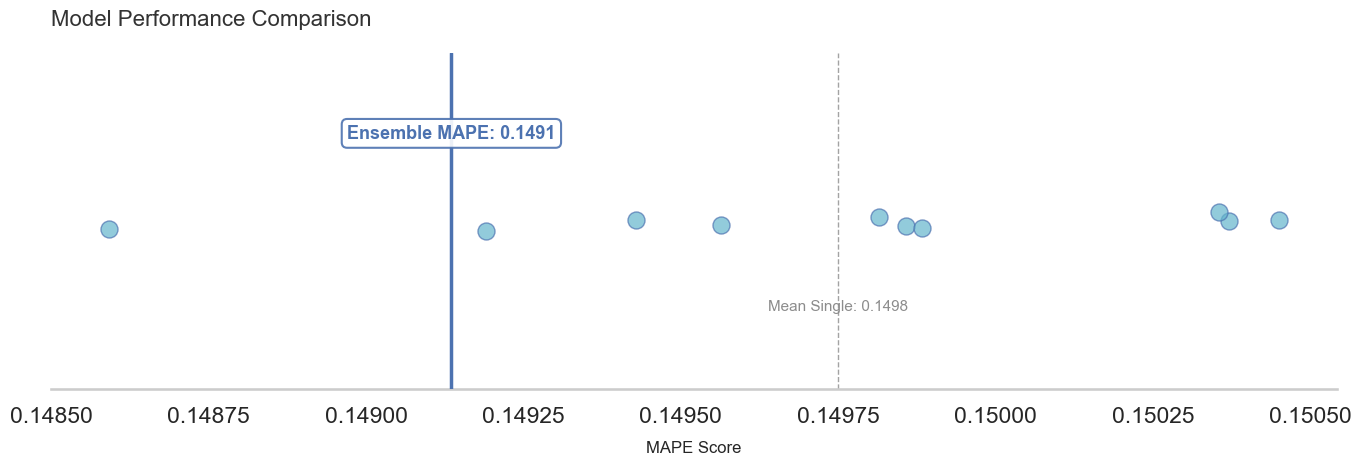

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Используем классическую палитру Seaborn
colors = sns.color_palette("deep")
MAIN_BLUE = colors[0]      # Классический синий
LIGHT_BLUE = colors[9]     # Светло-голубой/бирюзовый
GREY = colors[7]           # Серый для второстепенных линий

# Настройка стиля
sns.set_style("white")
plt.figure(figsize=(14, 5))

# Генерируем разброс по Y
jitter = np.random.uniform(-0.01, 0.01, size=len(individual_mapes))

# 1. Линия среднего (пунктир)
mean_mape = np.mean(individual_mapes)
plt.axvline(mean_mape, color=GREY, linestyle='--', linewidth=1, alpha=0.8, zorder=1)

# 2. Одиночные модели (точки)
plt.scatter(individual_mapes, jitter, 
            s=150, 
            color=LIGHT_BLUE, 
            edgecolor=MAIN_BLUE, 
            linewidth=1, 
            alpha=0.7, 
            zorder=2,
            label='Single Models')

# 3. Линия ансамбля - СДЕЛАЛИ ТОНЬШЕ (linewidth=2.5)
plt.axvline(ensemble_mape, color=MAIN_BLUE, linestyle='-', linewidth=2.5, zorder=3)

# 4. Текстовые аннотации (сдвинуты, чтобы не мешать линии)
# Надпись ансамбля сверху
plt.text(ensemble_mape, 0.07, f'Ensemble MAPE: {ensemble_mape:.4f}', 
         ha='center', va='bottom', fontsize=13, color=MAIN_BLUE, fontweight='bold',
         bbox=dict(facecolor='white', edgecolor=MAIN_BLUE, boxstyle='round,pad=0.3', alpha=0.9))

# Надпись среднего значения снизу
plt.text(mean_mape, -0.07, f'Mean Single: {mean_mape:.4f}', 
         ha='center', va='top', fontsize=11, color=GREY)

# 5. Оформление осей
plt.xlabel('MAPE Score', fontsize=12, labelpad=10)
plt.title('Model Performance Comparison', loc='left', fontsize=16, pad=20, color='#333333')

# Убираем лишнее
plt.ylim(-0.15, 0.15)
plt.yticks([])
ax = plt.gca()
sns.despine(left=True) # Удаляет верхнюю, правую и левую рамки через seaborn

# Настраиваем цвет нижней оси
ax.spines['bottom'].set_color('#cccccc')

plt.tight_layout()
plt.show()

# АНСАМБЛЬ

In [5]:
seeds = [42, 1, 10, 555, 777, 2024, 99, 123, 8, 21]

holdout_predictions = []
val_predictions_list = []

train_full = pd.concat([train, val], axis=0).reset_index(drop=True)
y_full_log = np.log1p(train_full[TARGET_COL])

print(f"Starting seed averaging ensemble with {len(seeds)} models...")
for i, s in enumerate(seeds):
    params['random_seed'] = s
    model = CatBoostRegressor(**params)
    model.fit(Pool(train_full[features], y_full_log, cat_features=cat_features), verbose=False)
    holdout_pred_log = model.predict(holdout[features])
    holdout_pred_real = np.maximum(np.expm1(holdout_pred_log), 0)
    holdout_predictions.append(holdout_pred_real)
    print(f"Model {i+1}/{len(seeds)} (seed {s}) trained.")

final_holdout_preds = np.mean(holdout_predictions, axis=0)

submission = pd.DataFrame({
    'id': holdout[ID_COL].values,
    'PREDICT': final_holdout_preds
})
# submission.to_csv('predictions_ensemble.csv', index=False)
submission

Starting seed averaging ensemble with 10 models...


KeyboardInterrupt: 

# АНСАМБЛЬ С СОХРАНЕНИЕМ ВЕСОВ


я закомментировал сохранялки за ненадобностью

In [ ]:
import os
import json

os.makedirs('models', exist_ok=True)

seeds = [42, 1, 10, 555, 777, 2024, 99, 123, 8, 21]
holdout_predictions = []

train_full = pd.concat([train, val], axis=0).reset_index(drop=True)
y_full_log = np.log1p(train_full[TARGET_COL])

metadata = {
    'features': features,
    'cat_features': cat_features,
    'best_params_found': best_params_found
}
# with open('models/metadata.json', 'w') as f:
#     json.dump(metadata, f)


for i, s in enumerate(seeds):
    current_params = params.copy()
    current_params['random_seed'] = s
    
    model = CatBoostRegressor(**current_params)
    model.fit(Pool(train_full[features], y_full_log, cat_features=cat_features), verbose=False)
    
    model_path = f'models/catboost_seed_{s}.cbm'
    # model.save_model(model_path)
    
    h_preds = np.maximum(np.expm1(model.predict(holdout[features])), 0)
    holdout_predictions.append(h_preds)
    
    print(f"Model {i+1}/{len(seeds)} (seed {s}) saved to {model_path}")

final_holdout_preds = np.mean(holdout_predictions, axis=0)
submission = pd.DataFrame({'id': holdout[ID_COL].values, 'PREDICT': final_holdout_preds})
# submission.to_csv('predictions_ensemble.csv', index=False)
submission

Starting seed averaging ensemble and saving models...
Model 1/10 (seed 42) saved to models/catboost_seed_42.cbm
Model 2/10 (seed 1) saved to models/catboost_seed_1.cbm
Model 3/10 (seed 10) saved to models/catboost_seed_10.cbm
Model 4/10 (seed 555) saved to models/catboost_seed_555.cbm
Model 5/10 (seed 777) saved to models/catboost_seed_777.cbm
Model 6/10 (seed 2024) saved to models/catboost_seed_2024.cbm
Model 7/10 (seed 99) saved to models/catboost_seed_99.cbm
Model 8/10 (seed 123) saved to models/catboost_seed_123.cbm
Model 9/10 (seed 8) saved to models/catboost_seed_8.cbm
Model 10/10 (seed 21) saved to models/catboost_seed_21.cbm
